In [1]:
import pandas as pd
import pypowsybl.network as pn
import pypowsybl as pp
from pypowsybl_jupyter import nad_explorer
import re
import networkx as nx
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [6]:
# handle malformed rows
data = pd.read_csv(
    "ieee300_active-perturbation.csv",
    sep=";",
    engine="python",

   # on_bad_lines="skip",
)

In [9]:
data.head()

,busId,type,slackValue_pu,slackValue,gen,controlevoltage,transfo,shunt,load,load_violation,gen_violation,info
0,VL1_0,P,-0.087044,-8.704352,NaN,NaN,NaN,NaN,VL1_0_load,0,0,23.56866:load_P
1,VL3_0,P,-0.013575,-1.357488,NaN,NaN,NaN,NaN,VL3_0_load,1,0,0.2:load_P
2,VL4_0,P,-0.009528,-0.952793,NaN,NaN,NaN,NaN,NaN,0,0,NaN
3,VL5_0,P,-0.060539,-6.053853,NaN,NaN,NaN,NaN,VL5_0_load,1,0,3.53:load_P
4,VL7_0,P,-0.015008,-1.500826,NaN,NaN,NaN,NaN,NaN,0,0,NaN


In [10]:
data = data.replace(r"\[", "", regex=True).replace(r"\]", "", regex=True)
data.head()

,busId,type,slackValue_pu,slackValue,gen,controlevoltage,transfo,shunt,load,load_violation,gen_violation,info
0,VL1_0,P,-0.087044,-8.704352,NaN,NaN,NaN,NaN,VL1_0_load,0,0,23.56866:load_P
1,VL3_0,P,-0.013575,-1.357488,NaN,NaN,NaN,NaN,VL3_0_load,1,0,0.2:load_P
2,VL4_0,P,-0.009528,-0.952793,NaN,NaN,NaN,NaN,NaN,0,0,NaN
3,VL5_0,P,-0.060539,-6.053853,NaN,NaN,NaN,NaN,VL5_0_load,1,0,3.53:load_P
4,VL7_0,P,-0.015008,-1.500826,NaN,NaN,NaN,NaN,NaN,0,0,NaN


In [39]:
len(data['busId'].unique())==len(data)

False

In [40]:
# Group by busId and aggregate to keep all information
# Group by busId (which is now the index) and aggregate to keep all information
data_grouped = data.groupby('busId')[['type', 'slackValue','info']].agg(list)
data_grouped


,type,slackValue,info
busId,,,
VL102_0,[P],[-1.859916],[0.778:load_P]
VL104_0,[P],[-3.127352],[0.086:load_P]
VL108_0,[P],[-4.202952],[100.0:pu_base;-99.99:gen_minP;99.99:gen_maxP;...
VL109_0,[P],[-7.386180],[0.307:load_P]
VL10_0,[P],[-1.823225],[100.0:pu_base;-0.05:gen_P;1.48:load_P;-99.99:...
...,...,...,...
VL9051_3,[V],[6.900000],[13.8:bus_nominalV;1.4999999950089893:bus_V]
VL92_0,[V],[5.199982],[115.0:bus_nominalV;1.0972172363576813:bus_V]
VL94_0,[P],[-4.434060],[0.603:load_P]


In [41]:
len(data_grouped.index.unique())==len(data_grouped)

True

In [42]:
namefile_initial = 'ieee300-voltage-perturbation'
extension_in = '.xiidm'
extension_out = '.svg'
# possibilité de lire un network ou d'importer directement les IEEE
network = pn.load('./Outputs/' + namefile_initial + extension_in)

In [70]:
nad_explorer(network)

In [44]:
G_slack = nx.Graph()
# add bus nodes
for bus in data["busId"]:
    bus_name = str(bus)
    G_slack.add_node(bus_name)

In [ ]:
def visualize_graph(G, with_labels=True, k=None, alpha=1.0, node_shape='o'):
    #nx.draw_spring(G, with_labels=with_labels, alpha = alpha)
    pos = nx.spring_layout(G, k=k)
    if with_labels:
        lab = nx.draw_networkx_labels(G, pos, labels=dict([(n, n) for n in G.nodes()]))
    ec = nx.draw_networkx_edges(G, pos, alpha=alpha)
    nc = nx.draw_networkx_nodes(G, pos, nodelist=G.nodes(), node_color='g', node_shape=node_shape)
    plt.axis('off')

def describe_graph(G):
    print(G)
    if nx.is_connected(G):
        print("Avg. Shortest Path Length: %.4f" %nx.average_shortest_path_length(G))
        print("Diameter: %.4f" %nx.diameter(G)) # Longest shortest path
    else:
        print("Graph is not connected")
        print("Diameter and Avg shortest path length are not defined!")
    print("Sparsity: %.4f" %nx.density(G))  # #edges/#edges-complete-graph
    # #closed-triplets(3*#triangles)/#all-triplets
    print("Global clustering coefficient aka Transitivity: %.4f" %nx.transitivity(G))

def plot_degree_distribution(G):
    degrees = {}
    for node in G.nodes():
        degree = G.degree(node)
        if degree not in degrees:
            degrees[degree] = 0
        degrees[degree] += 1
    sorted_degree = sorted(degrees.items())
    deg = [k for (k,v) in sorted_degree]
    cnt = [v for (k,v) in sorted_degree]
    fig, ax = plt.subplots()
    plt.bar(deg, cnt, width=0.80, color='b')
    plt.title("Degree Distribution")
    plt.ylabel("Frequency")
    plt.xlabel("Degree")
    ax.set_xticks([d+0.05 for d in deg])
    ax.set_xticklabels(deg)

In [46]:
G_slack.nodes()

NodeView(('VL1_0', 'VL3_0', 'VL4_0', 'VL5_0', 'VL7_0', 'VL8_0', 'VL9_0', 'VL10_0', 'VL10_1', 'VL11_0', 'VL13_0', 'VL14_0', 'VL15_1', 'VL19_0', 'VL20_0', 'VL21_0', 'VL22_0', 'VL26_0', 'VL27_0', 'VL47_0', 'VL69_0', 'VL70_0', 'VL71_0', 'VL72_0', 'VL73_0', 'VL76_0', 'VL85_0', 'VL86_0', 'VL87_0', 'VL94_0', 'VL99_0', 'VL102_0', 'VL104_0', 'VL108_0', 'VL109_0', 'VL110_0', 'VL112_0', 'VL113_0', 'VL114_0', 'VL115_0', 'VL115_1', 'VL116_0', 'VL116_1', 'VL117_0', 'VL118_0', 'VL119_0', 'VL120_0', 'VL122_0', 'VL123_0', 'VL125_0', 'VL126_0', 'VL127_0', 'VL128_0', 'VL129_0', 'VL130_0', 'VL130_1', 'VL130_2', 'VL132_0', 'VL132_1', 'VL133_0', 'VL134_0', 'VL135_0', 'VL139_0', 'VL154_0', 'VL157_0', 'VL158_0', 'VL159_0', 'VL160_0', 'VL167_0', 'VL168_0', 'VL169_0', 'VL170_0', 'VL171_0', 'VL172_0', 'VL173_0', 'VL179_0', 'VL182_0', 'VL184_0', 'VL185_0', 'VL193_0', 'VL193_1', 'VL199_0', 'VL200_0', 'VL201_0', 'VL205_0', 'VL206_0', 'VL207_0', 'VL208_0', 'VL248_0', 'VL249_0', 'VL319_0', 'VL320_0', 'VL322_0', 'VL32

In [47]:
network.get_bus_breaker_view_buses()#[network.get_bus_breaker_view_buses()["bus_id"] == 'VL115_0']
#network.get_bus_breaker_view_buses()[network.get_bus_breaker_view_buses()["connected_component"] != 0]

,name,v_mag,v_angle,connected_component,synchronous_component,voltage_level_id,bus_id
id,,,,,,,
B1,1,118.016948,-0.510341,0,0,VL1,VL1_0
B2,1,118.880740,1.392074,0,0,VL1,VL1_1
B3,1,228.201478,0.175390,0,0,VL3,VL3_0
B4,1,354.215466,-1.577107,0,0,VL4,VL4_0
B7001,1,14.499660,4.341826,0,0,VL7001,VL7001_0
...,...,...,...,...,...,...,...
B9023,1,6.436461,-23.099350,0,0,VL9023,VL9023_0
B9025,1,0.579254,-24.114538,0,0,VL9025,VL9025_0
B9026,1,0.579756,-24.029090,0,0,VL9025,VL9025_1


In [71]:
network.get_branches()[network.get_branches()["bus1_id"] == 'VL5_0']

,type,voltage_level1_id,bus1_id,connected1,voltage_level2_id,bus2_id,connected2,p1,q1,i1,p2,q2,i2
id,,,,,,,,,,,,,
L5-9-1,LINE,VL5,VL5_0,True,VL9,VL9_0,True,116.1042,28.15687,589.993198,-115.272476,-25.970514,592.071164


In [72]:
network.get_terminals()[network.get_terminals()["bus_id"]=='VL5_0']

,voltage_level_id,bus_id,element_side,connected
element_id,,,,
T7-5-1,VL5,VL5_0,TWO,True
L5-9-1,VL5,VL5_0,ONE,True
L1-5-1,VL5,VL5_0,TWO,True
B5-L,VL5,VL5_0,,True


In [73]:
network.get_loads()[network.get_loads()["bus_id"]=='VL5_0']

,name,type,p0,q0,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,
B5-L,,UNDEFINED,353.0,130.0,353.0,130.0,1857.725253,VL5,VL5_0,True


In [74]:
network.get_shunt_compensators()[network.get_shunt_compensators()["bus_id"]=='VL5_0']

,name,g,b,model_type,max_section_count,section_count,solved_section_count,voltage_regulation_on,target_v,target_deadband,regulating_bus_id,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,,,,,,,,


In [75]:

print("\n=== All Terminals at VL117_0 ===")
network.get_terminals()[network.get_terminals()["bus_id"] == 'VL5_0']


=== All Terminals at VL117_0 ===


,voltage_level_id,bus_id,element_side,connected
element_id,,,,
T7-5-1,VL5,VL5_0,TWO,True
L5-9-1,VL5,VL5_0,ONE,True
L1-5-1,VL5,VL5_0,TWO,True
B5-L,VL5,VL5_0,,True


In [53]:
network.get_shunt_compensators()[network.get_shunt_compensators()["voltage_regulation_on"]== False].head()

,name,g,b,model_type,max_section_count,section_count,solved_section_count,voltage_regulation_on,target_v,target_deadband,regulating_bus_id,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,,,,,,,,
B117-SH,,0.0,0.024575,LINEAR,1,1,NaN,False,NaN,NaN,VL117_0,0.0,-229.868127,1372.216355,VL117,VL117_0,True
B120-SH,,0.0,0.004159,LINEAR,1,1,NaN,False,NaN,NaN,VL120_0,0.0,-48.251128,258.628637,VL120,VL120_0,True
B154-SH,,0.0,0.002609,LINEAR,1,1,NaN,False,NaN,NaN,VL154_0,0.0,-32.214742,167.370305,VL154,VL154_0,True
B164-SH,,0.0,-0.004008,LINEAR,1,1,NaN,False,NaN,NaN,VL155_1,0.0,204.370400,522.502610,VL155,VL155_1,True
B166-SH,,0.0,-0.001947,LINEAR,1,1,NaN,False,NaN,NaN,VL166_0,0.0,102.349296,257.734513,VL166,VL166_0,True


In [54]:
# Get all elements at VL117_0
print("=== Generators at VL117_0 ===")
print(network.get_generators()[network.get_generators()["bus_id"] == 'VL7_0'])

print("\n=== Loads at VL117_0 ===")
print(network.get_loads()[network.get_loads()["bus_id"] == 'VL7_0'])

print("\n=== Shunt Compensators at VL117_0 ===")
print(network.get_shunt_compensators()[network.get_shunt_compensators()["bus_id"] == 'VL7_0'])

print("\n=== Branches (Lines/Transformers) connected to VL117_0 ===")
print(network.get_branches()[(network.get_branches()["bus1_id"] == 'VL7_0') | (network.get_branches()["bus2_id"] == 'VL7_0')])

print("\n=== All Terminals at VL117_0 ===")
print(network.get_terminals()[network.get_terminals()["bus_id"] == 'VL7_0'])

=== Generators at VL117_0 ===
Empty DataFrame
Columns: [name, energy_source, target_p, min_p, max_p, min_q, max_q, rated_s, reactive_limits_kind, target_v, target_q, voltage_regulator_on, regulated_element_id, p, q, i, voltage_level_id, bus_id, connected]
Index: []

=== Loads at VL117_0 ===
Empty DataFrame
Columns: [name, type, p0, q0, p, q, i, voltage_level_id, bus_id, connected]
Index: []

=== Shunt Compensators at VL117_0 ===
Empty DataFrame
Columns: [name, g, b, model_type, max_section_count, section_count, solved_section_count, voltage_regulation_on, target_v, target_deadband, regulating_bus_id, p, q, i, voltage_level_id, bus_id, connected]
Index: []

=== Branches (Lines/Transformers) connected to VL117_0 ===
                              type voltage_level1_id bus1_id  connected1  \
id                                                                         
L3-7-1                        LINE               VL3   VL3_0        True   
L7-12-1                       LINE              

In [55]:
network.get_generators()[network.get_generators()["bus_id"] == 'VL115_0']

,name,energy_source,target_p,min_p,max_p,min_q,max_q,rated_s,reactive_limits_kind,target_v,target_q,voltage_regulator_on,regulated_element_id,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,,,,,,,,,,


In [56]:
edges_list = network.get_branches()
edges_list.head()

,type,voltage_level1_id,bus1_id,connected1,voltage_level2_id,bus2_id,connected2,p1,q1,i1,p2,q2,i2
id,,,,,,,,,,,,,
L9001-9005-1,LINE,VL37,VL37_1,True,VL9005,VL9005_0,True,36.101501,-10.152636,186.697994,-36.090437,10.200761,186.697994
L9006-9007-1,LINE,VL9006,VL9006_0,True,VL9007,VL9007_0,True,9.117783,2.598722,828.755193,-9.067896,-2.377331,828.755193
L9006-9003-1,LINE,VL9006,VL9006_0,True,VL9003,VL9003_0,True,8.089913,2.194617,732.724119,-8.011909,-1.848503,732.724119
L9006-9003-2,LINE,VL9006,VL9006_0,True,VL9003,VL9003_0,True,8.089913,2.194617,732.724119,-8.011909,-1.848503,732.724119
L9012-9002-1,LINE,VL9006,VL9006_1,True,VL9002,VL9002_0,True,6.431389,0.555946,563.897260,-6.399717,-0.376077,563.897260


In [57]:
G = nx.from_pandas_edgelist(edges_list,'bus1_id','bus2_id', edge_attr=True,create_using=nx.Graph())

In [58]:
print(G)
describe_graph(G)

Graph with 300 nodes and 409 edges
Graph with 300 nodes and 409 edges
Avg. Shortest Path Length: 9.9353
Diameter: 24.0000
Sparsity: 0.0091
Global clustering coefficient aka Transitivity: 0.0960


In [59]:
nx.set_node_attributes(G, data_grouped['slackValue'],'slack')
nx.set_node_attributes(G, data_grouped['type'],'type')
#nx.get_node_attributes(G, data['type'].to_dict(),'type')


In [60]:
G.nodes(data=True)

NodeDataView({'VL37_1': {}, 'VL9005_0': {}, 'VL9006_0': {}, 'VL9007_0': {}, 'VL9003_0': {}, 'VL9006_1': {}, 'VL9002_0': {}, 'VL9021_0': {}, 'VL9023_0': {}, 'VL9044_0': {}, 'VL9004_0': {}, 'VL9121_0': {}, 'VL1_0': {'slack': ['-8.704352'], 'type': ['P']}, 'VL5_0': {'slack': ['-6.053853'], 'type': ['P']}, 'VL1_1': {}, 'VL5_1': {}, 'VL8_0': {'slack': ['-1.210847', '0.197294'], 'type': ['P', 'V']}, 'VL3_0': {'slack': ['-1.357488'], 'type': ['P']}, 'VL7_0': {'slack': ['-1.500826'], 'type': ['P']}, 'VL19_0': {'slack': ['-3.277014'], 'type': ['P']}, 'VL130_2': {'slack': ['-0.967414'], 'type': ['P']}, 'VL4_0': {'slack': ['-0.952793'], 'type': ['P']}, 'VL16_0': {}, 'VL9_0': {'slack': ['-4.905558'], 'type': ['P']}, 'VL10_1': {'slack': ['-1.784792'], 'type': ['P']}, 'VL130_1': {'slack': ['-0.915528'], 'type': ['P']}, 'VL11_0': {'slack': ['-1.754724'], 'type': ['P']}, 'VL14_0': {'slack': ['-4.059460'], 'type': ['P']}, 'VL13_0': {'slack': ['-3.460383'], 'type': ['P']}, 'VL21_0': {'slack': ['-3.62987

In [61]:
pertubation = [n for n in G.nodes if n in G_slack.nodes]
pos = nx.spring_layout(G, seed=42)

In [62]:
G.edges(data=True)

EdgeDataView([('VL37_1', 'VL9005_0', {'type': 'LINE', 'voltage_level1_id': 'VL37', 'connected1': True, 'voltage_level2_id': 'VL9005', 'connected2': True, 'p1': 36.101500674513886, 'q1': -10.15263555232782, 'i1': 186.69799427917226, 'p2': -36.09043733533746, 'q2': 10.200761077734914, 'i2': 186.6979942791599}), ('VL37_1', 'VL37_0', {'type': 'TWO_WINDINGS_TRANSFORMER', 'voltage_level1_id': 'VL37', 'connected1': True, 'voltage_level2_id': 'VL37', 'connected2': True, 'p1': 78.37571213769195, 'q1': 4.2414290739931335, 'i1': 387.54980881973256, 'p2': -78.37207787239277, 'q2': -4.21356637342032, 'i2': 390.72771725198777}), ('VL37_1', 'VL9006_0', {'type': 'TWO_WINDINGS_TRANSFORMER', 'voltage_level1_id': 'VL37', 'connected1': True, 'voltage_level2_id': 'VL9006', 'connected2': True, 'p1': 25.46535998637226, 'q1': 9.992365320488645, 'i1': 136.18624035695782, 'p2': -25.297607687480628, 'q2': -6.987955349113549, 'i2': 2294.1603902071643}), ('VL37_1', 'VL9006_1', {'type': 'TWO_WINDINGS_TRANSFORMER', 

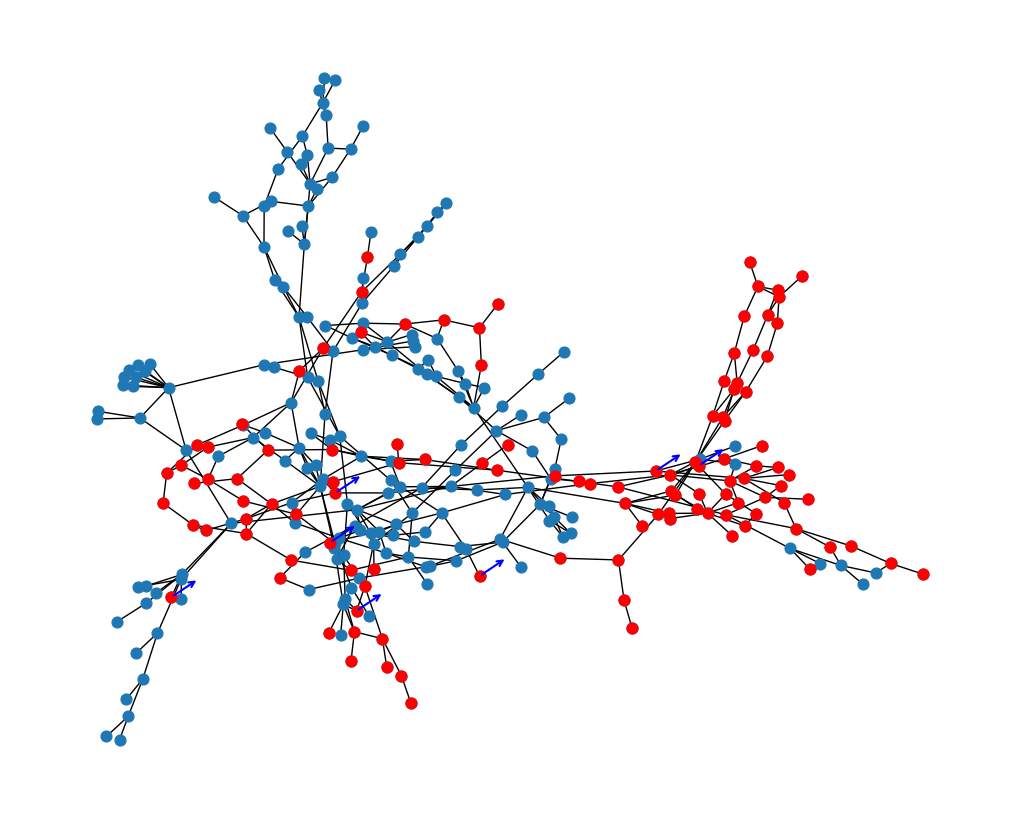

In [63]:

plt.figure(figsize=(10, 8))
nx.draw(G, pos=pos, with_labels=False, node_size=60)
nx.draw_networkx_nodes(G, pos=pos, nodelist=pertubation, node_size=60, node_color="red")
#if "VL2_0" in G.nodes:
#   nx.draw_networkx_nodes(G, pos=pos, nodelist=["VL2_0"], node_size=60, node_color="green")

# ensure slackValue is numeric
data["slackValue"] = pd.to_numeric(data["slackValue"], errors="coerce")

# add arrows for buses with non-zero slack
for _, r in data[data["slackValue"] != 0].iterrows():
    n = str(r["busId"]).strip("[]")
    if n in pos:
        x, y = pos[n]
        if r["slackValue"] > 0:
            plt.annotate(
                "",
                xy=(x, y),
                xytext=(x + 0.05, y + 0.05),
                arrowprops=dict(arrowstyle="<-", color="blue", lw=1.5),
            )
        elif r["slackValue"] > 0:
            plt.annotate(
                "",
                xy=(x, y),
                xytext=(x - 0.05, y - 0.05),
                arrowprops=dict(arrowstyle="->", color="orange", lw=1.5),
            )
plt.show()

In [64]:
G_slack.nodes

NodeView(('VL1_0', 'VL3_0', 'VL4_0', 'VL5_0', 'VL7_0', 'VL8_0', 'VL9_0', 'VL10_0', 'VL10_1', 'VL11_0', 'VL13_0', 'VL14_0', 'VL15_1', 'VL19_0', 'VL20_0', 'VL21_0', 'VL22_0', 'VL26_0', 'VL27_0', 'VL47_0', 'VL69_0', 'VL70_0', 'VL71_0', 'VL72_0', 'VL73_0', 'VL76_0', 'VL85_0', 'VL86_0', 'VL87_0', 'VL94_0', 'VL99_0', 'VL102_0', 'VL104_0', 'VL108_0', 'VL109_0', 'VL110_0', 'VL112_0', 'VL113_0', 'VL114_0', 'VL115_0', 'VL115_1', 'VL116_0', 'VL116_1', 'VL117_0', 'VL118_0', 'VL119_0', 'VL120_0', 'VL122_0', 'VL123_0', 'VL125_0', 'VL126_0', 'VL127_0', 'VL128_0', 'VL129_0', 'VL130_0', 'VL130_1', 'VL130_2', 'VL132_0', 'VL132_1', 'VL133_0', 'VL134_0', 'VL135_0', 'VL139_0', 'VL154_0', 'VL157_0', 'VL158_0', 'VL159_0', 'VL160_0', 'VL167_0', 'VL168_0', 'VL169_0', 'VL170_0', 'VL171_0', 'VL172_0', 'VL173_0', 'VL179_0', 'VL182_0', 'VL184_0', 'VL185_0', 'VL193_0', 'VL193_1', 'VL199_0', 'VL200_0', 'VL201_0', 'VL205_0', 'VL206_0', 'VL207_0', 'VL208_0', 'VL248_0', 'VL249_0', 'VL319_0', 'VL320_0', 'VL322_0', 'VL32

In [65]:
data["busId"]=data["busId"].str.replace(r"\bVL", "VL-", regex=True)

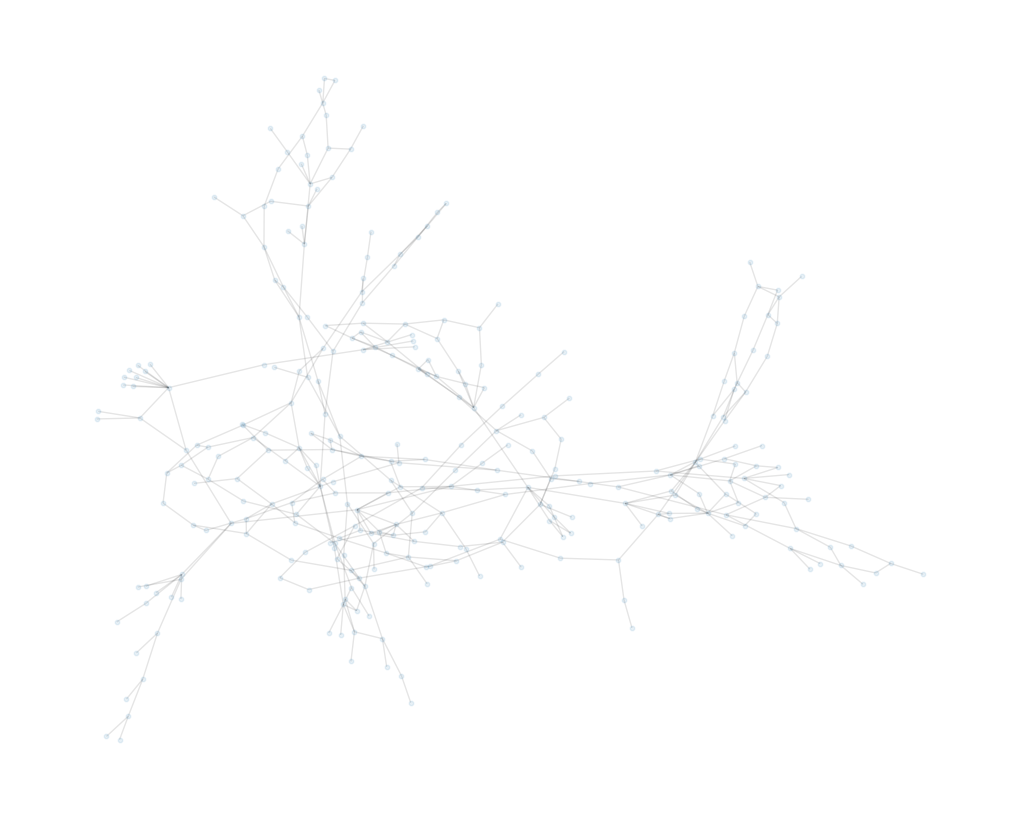

In [66]:
nodes_to_show = [str(n).strip("[]") for n in data["busId"].unique()]
nodes_to_show = [n for n in nodes_to_show if n in G.nodes]

plt.figure(figsize=(10, 8))
nx.draw(G, pos=pos, with_labels=False, node_size=10, alpha=0.1)
nx.draw_networkx_nodes(G, pos=pos, nodelist=nodes_to_show, node_size=20, node_color="red")
nx.draw_networkx_labels(G, pos=pos, labels={n: n for n in nodes_to_show}, font_size=6)
plt.show()

In [67]:
hover_line = [f"- <br>type: {n.get('type', 'N/A')}" for n in G.edges[n]]

ValueError: too many values to unpack (expected 2)

In [ ]:
def plot_graph(G, pos, highlight=None):
    highlight = highlight or []
    hover_line = [f"{u} - {v}<br>type: {d.get('type', 'N/A')}" for u, v, d in G.edges(data=True)]
    hover_text = [f"{n}<br>slack: {G.nodes[n].get('slack', 'N/A')} <br>type: {G.nodes[n].get('type', 'N/A')}" 
              for n in G.nodes()]

    edge_x = [coord for u, v in G.edges() for coord in (pos[u][0], pos[v][0], None)]
    edge_y = [coord for u, v in G.edges() for coord in (pos[u][1], pos[v][1], None)]

    node_x = [pos[n][0] for n in G.nodes()]
    node_y = [pos[n][1] for n in G.nodes()]
  
    #hl_x = [pos[n][0] for n in highlight]
    #hl_y = [pos[n][1] for n in highlight]

    # Determine colors based on slack values
    node_colors = []
    for n in G.nodes():
        slack = G.nodes[n].get('slack', None)
        # Check if slack is not null/None and not zero
        if slack is not None and slack != 'N/A':
            # Handle case where slack might be a list
            if isinstance(slack, list):
                # Check if any value in the list is non-zero
                if any(float(s) != 0 for s in slack if s):
                    node_colors.append('red')
                else:
                    node_colors.append('black')
        else:
            node_colors.append('black')
    
    fig = go.Figure([
        go.Scatter(x=edge_x, y=edge_y, mode="lines",
                   line=dict(width=0.5, color='gray'), hoverinfo="text", name="connection", 
                   text=hover_line,
                   hovertemplate='%{text}<extra></extra>'),
        go.Scatter(x=node_x, y=node_y, mode="markers",
                   marker=dict(size=8, color=node_colors), hoverinfo="text", 
                   name="buses", text=hover_text, hovertemplate='%{text}<extra></extra>')
    ])

    fig.update_layout(
        width=800, height=600,
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        margin=dict(l=10, r=10, t=10, b=10),
        showlegend=True
    )
    return fig


In [ ]:
plot_graph(G, pos, pertubation).show()
# differentiate lines and transfo 
# in the hover : slack type / value 
